In [ ]:
from datasets import load_dataset, DatasetDict
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, f1_score
from transformers import AutoModelForSequenceClassification, AutoTokenizer, DataCollatorWithPadding, TrainingArguments, Trainer
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

os.environ["WANDB_DISABLED"] = "true"

In [ ]:
# Path to prepared data
data_path = "/content/fever_train_ready.jsonl"

# Load dataset from JSONL
dataset = load_dataset("json", data_files={"train": data_path})

# Label mapping
label_map = {"SUPPORTS": 0, "REFUTES": 1}

def map_labels(example):
    example["label"] = label_map.get(example["label"], -1)
    return example

# Apply mapping and remove invalid rows
dataset["train"] = (
    dataset["train"]
    .map(map_labels)
    .filter(lambda x: x["label"] != -1)
)

# Split train into train/validation
split_dataset = dataset["train"].train_test_split(test_size=0.1, seed=42)

# Rebuild into Hugging Face format
dataset = DatasetDict({
    "train": split_dataset["train"],
    "validation": split_dataset["test"]
})

print(f"Train size: {len(dataset['train'])}")
print(f"Validation size: {len(dataset['validation'])}")


Train size: 18000
Validation size: 2000


In [ ]:
def combine_text(example):
    example["text"] = f"claim: {example['claim']} evidence: {example['evidence_sentences']}"
    return example

def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="macro")
    }

val_dataset = dataset['validation'].map(combine_text)

In [ ]:
pd.set_option('display.max_colwidth', 150)
pd.DataFrame(val_dataset.select_columns(["text", "label"])[:5])

,text,label
0,"claim: Colin Firth was in a 2009 American drama film called A Single Man. evidence: ['In 2009 , Firth received widespread critical acclaim for his...",0
1,"claim: Hannah Simone was an animal. evidence: ['Hannah Simone -LRB- born August 3 , 1980 -RRB- is a British-Canadian television host , actress , a...",1
2,claim: Life Is Peachy is the second film by Denis Villeneuve. evidence: ['Life Is Peachy is the second studio album by the American nu metal band ...,1
3,"claim: Frank Zappa's debut was released in 1966. evidence: ['His 1966 debut album with the Mothers of Invention , Freak Out !\tthe Mothers of Inve...",0
4,"claim: Nicki Minaj grew up in the UK. evidence: [""Born in Saint James , Trinidad and Tobago -LRB- a district of Trinidad 's capital Port of Spain ...",1


In [ ]:
def tokenize(example, tokenizer):
    return tokenizer(example["text"], truncation=True, max_length=256)

In [ ]:
models = {
    "Base Gemma-270M": "google/gemma-3-270m",
    "Finetuned Gemma-270M": "rajyalakshmijampani/fever_gemma3_250M",
    "Base DeBERTa": "microsoft/deberta-v3-base",
    "Finetuned DeBERTa": "rajyalakshmijampani/fever_finetuned_deberta",
    "BART-large": "facebook/bart-large-mnli",
}

In [ ]:
results = {}

for name, model_path in models.items():
    global tokenizer
    print(f"\n ===============Evaluating {name} ...================= \n")
    try:
        model = AutoModelForSequenceClassification.from_pretrained(model_path, num_labels=2)
        tokenizer = AutoTokenizer.from_pretrained(model_path)
        tokenizer.pad_token = tokenizer.eos_token

        processed_val_dataset = val_dataset.map(tokenize, batched=True, fn_kwargs={"tokenizer": tokenizer})
        processed_val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])


        trainer = Trainer(model= model,
                          eval_dataset=processed_val_dataset,
                          tokenizer=tokenizer,
                          compute_metrics=compute_metrics)

        predictions = trainer.predict(processed_val_dataset)
        y_true = predictions.label_ids
        y_pred = np.argmax(predictions.predictions, axis=1)

        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro')

        print(f"Accuracy: {acc}")
        print(f"F1 Score: {f1}")

        results[name] = {"accuracy": acc,
                        "f1_score": f1}

    except Exception as e:
        print(f"❌ Failed for {name}: {e}")


 ===============Evaluating Base Gemma-270M ...================= 



Some weights of Gemma3TextForSequenceClassification were not initialized from the model checkpoint at google/gemma-3-270m and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2307196340.py:15: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model= model,
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Accuracy: 0.5125
F1 Score: 0.4041054385004726

 ===============Evaluating Finetuned Gemma-270M ...================= 



model.safetensors:   0%|          | 0.00/1.07G [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

/tmp/ipython-input-2307196340.py:15: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model= model,
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Accuracy: 0.95
F1 Score: 0.9499959496719235

 ===============Evaluating BART-large ...================= 



config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

❌ Failed for BART-large: Error(s) in loading state_dict for Linear:
	size mismatch for bias: copying a param with shape torch.Size([3]) from checkpoint, the shape in current model is torch.Size([2]).


In [ ]:
results

{'Base Gemma-270M': {'accuracy': 0.5125, 'f1_score': 0.4041054385004726},
 'Finetuned Gemma-270M': {'accuracy': 0.8835, 'f1_score': 0.8834556840238501},
 'Base DeBERTa': {'accuracy': 0.5015, 'f1_score': 0.333999333999334},
 'Finetuned DeBERTa': {'accuracy': 0.95, 'f1_score': 0.9499959496719235}}

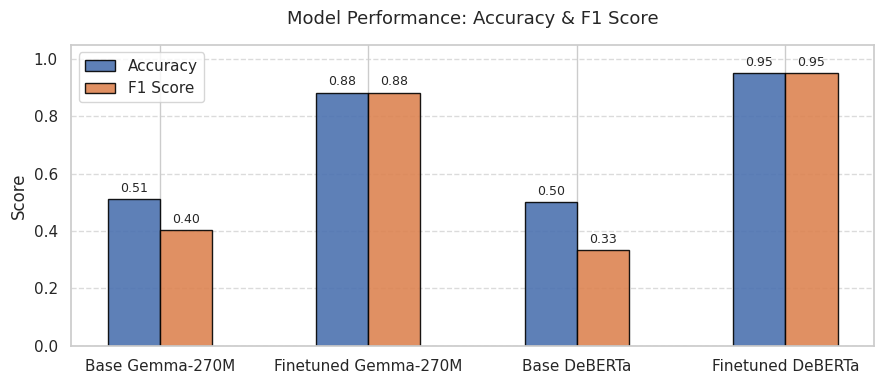

In [ ]:
models = list(results.keys())
accuracy = [v["accuracy"] for v in results.values()]
f1_score_vals = [v["f1_score"] for v in results.values()]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(9, 4))

# Bars with black borders
bars1 = plt.bar(x - width/2, accuracy, width,
                label='Accuracy', alpha=0.9,
                edgecolor='black', linewidth=1)
bars2 = plt.bar(x + width/2, f1_score_vals, width,
                label='F1 Score', alpha=0.9,
                edgecolor='black', linewidth=1)

# Add numeric labels on top
for bars in [bars1, bars2]:
    plt.bar_label(bars, fmt='%.2f', fontsize=9, padding=3)

plt.xticks(x, models, ha='center')
plt.ylabel("Score")
plt.title("Model Performance: Accuracy & F1 Score", fontsize=13, pad=15)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()